In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

import os

os.makedirs('pics', exist_ok=True)


In [2]:
Co2l = "0.2"
NCLUSTERS = 100
groupsize = 60


In [3]:
def get_emissions(n):

    gen = (
        n.generators_t.p
        .multiply(n.snapshot_weightings.objective,axis=0) # multiply by no. of hours (weight)
        .divide(n.generators.efficiency,axis=1).fillna(0) # efficiency and generation might be different (e.g. in the case of CCGT)
        .multiply(n.generators.carrier.map(n.carriers.co2_emissions)) # multiply by specific emissions
        .fillna(0).sum().sum()
    )

    stog = (
        n.storage_units_t.p
        .multiply(n.snapshot_weightings.objective,axis=0)
        .divide(n.storage_units.efficiency_dispatch,axis=1).fillna(0)
        .multiply(n.storage_units.carrier.map(n.carriers.co2_emissions))
        .fillna(0).sum().sum()
    )

    return gen+stog

In [4]:
Co2_scenarios = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

os.makedirs('pics/lopf', exist_ok=True)

# Define the carriers
renewable_carriers = ["solar", "solar-hsat", "onwind", "offwind-ac", "offwind-dc", "offwind-float", "hydro"]
conventional_carriers = ["nuclear", "oil", "OCGT", "CCGT", "coal", "lignite", "geothermal", "biomass"]

# Combine them into a single list for the DataFrame columns
all_carriers = renewable_carriers + conventional_carriers#network.gener.index

generation_by_carrier_and_co2l = pd.DataFrame(None,index=all_carriers, columns= Co2_scenarios)

CO2_shadowprices = pd.Series(index = Co2_scenarios)
CO2_values = pd.Series(index = Co2_scenarios)
lopf_CO2_global = pd.Series(index = Co2_scenarios)
# emissions = pd.Dataframe(None,index = [0], columns = Co2_scenarios)

for Co2l in Co2_scenarios:

    network = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc") ## lopf network

    shadow_CO2 = network.global_constraints["mu"]["CO2Limit"]
    lopf_CO2_global[Co2l] = network.global_constraints["constant"]["CO2Limit"]

    CO2_shadowprices[Co2l] = shadow_CO2
    CO2_values[Co2l] = get_emissions(network)

    print(f"{Co2l} CO2 shadow price: {shadow_CO2}")


    df = network.generators_t.p.sum(axis=0)
    
    # remove carrier id
    df.index = df.index.str[6:]
    # aggregate same carrier types
    df = df.groupby(df.index).sum()


    for carrier in df.index:
        
        # print(f"{carrier} {df[carrier]}")
        generation_by_carrier_and_co2l.loc[carrier, Co2l] = df[carrier]
        # generation_by_carrier_and_co2l.loc[carrier, "co2_emissions"] = network.carriers.co2_emissions[carrier]#df[carrier]
        
    
    # plot energy balance with inbuilt energy_balance method
    
    # number of different carriers
    num_bars = len(network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum())
    
    # colors
    cmap = matplotlib.colormaps.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, num_bars))
    
    # plot
    fig, ax = plt.subplots(figsize=(10, 6),layout = "constrained")
    # tmp.rename({"-":"Load"},inplace=True)
    # data in plot
    # energy_balance_data = 
    network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum().rename({"-":"Load"}).to_frame().T.plot.bar(stacked=True, ax=ax, color=colors, title=f"Energy Balance {Co2l}")
    
    
    ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
    fig.savefig(f"pics/lopf/Energymix_lopf_{Co2l}-{NCLUSTERS}.pdf")
    plt.close()



INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.05 CO2 shadow price: -206.68681533699103


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.1 CO2 shadow price: -76.30303345257728


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


...

0.4 CO2 shadow price: -21.638301456441116


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.5.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.5 CO2 shadow price: -14.242812022248023


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.6.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.6 CO2 shadow price: -4.814621380802903


In [5]:
CO2_shadowprices

0.05   -206.686815
0.10    -76.303033
0.20    -40.071704
0.30    -31.977848
0.40    -21.638301
0.50    -14.242812
0.60     -4.814621
dtype: float64

### Test w/ statistics module

In [6]:
n = network

groupers = n.statistics.groupers
n.statistics.supply(groupby=groupers.get_carrier)

dftmp = pd.DataFrame(n.statistics.supply(groupby=groupers.get_carrier)
)

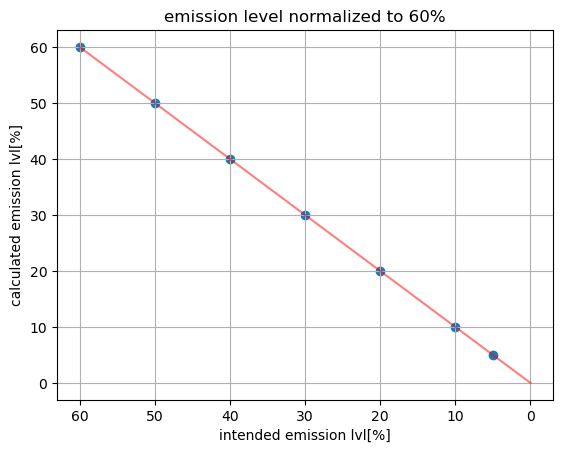

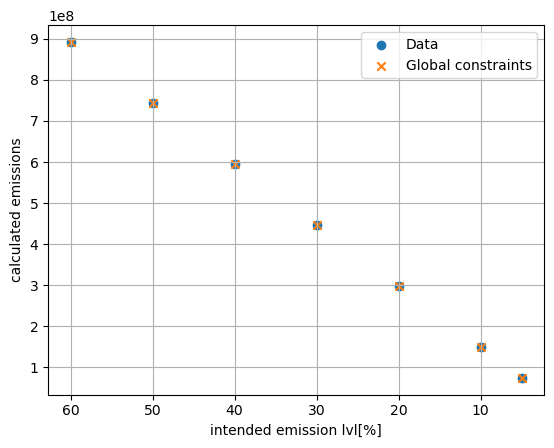

In [7]:
# generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
# fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100

# emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
# emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = CO2_values#emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.6]*60

# plot red line
plt.plot([60,0],[60,0], color = "r", alpha = 0.5)
# plot 

plt.scatter(emission_by_co2l_perc.index*100, emission_by_co2l_perc.values)

plt.gca().invert_xaxis()
plt.grid()
plt.title("emission level normalized to 60%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")

plt.figure()
plt.scatter(emission_by_co2l.index*100, emission_by_co2l.values,label = "Data")
plt.scatter(lopf_CO2_global.index*100, lopf_CO2_global.values,label = "Global constraints",marker = "x")

plt.legend()
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")
plt.savefig(f"pics/lopf/emissions.pdf")

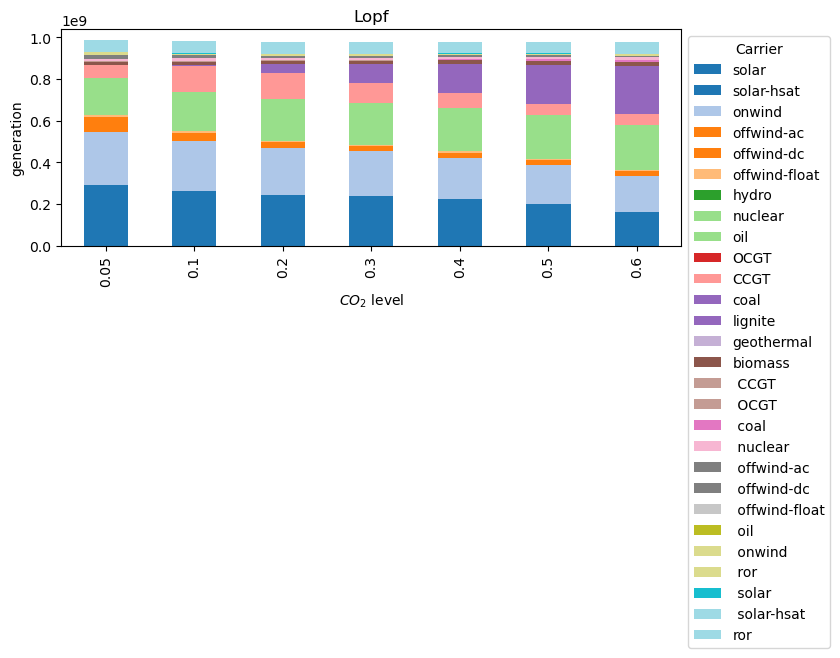

In [8]:
cmap = matplotlib.colormaps.get_cmap('tab20')
num_bars = len(generation_by_carrier_and_co2l)
colors = cmap(np.linspace(0, 1, num_bars))


fig, ax = plt.subplots(figsize= (10,5))
generation_by_carrier_and_co2l.T.plot(kind='bar', stacked=True,color=colors, ax = ax)

ax.set_xlabel("$CO_2$ level")
ax.set_ylabel("generation")
ax.set_title("Lopf")
ax.legend(title='Carrier', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

fig.savefig("pics/lopf/Generation.pdf")

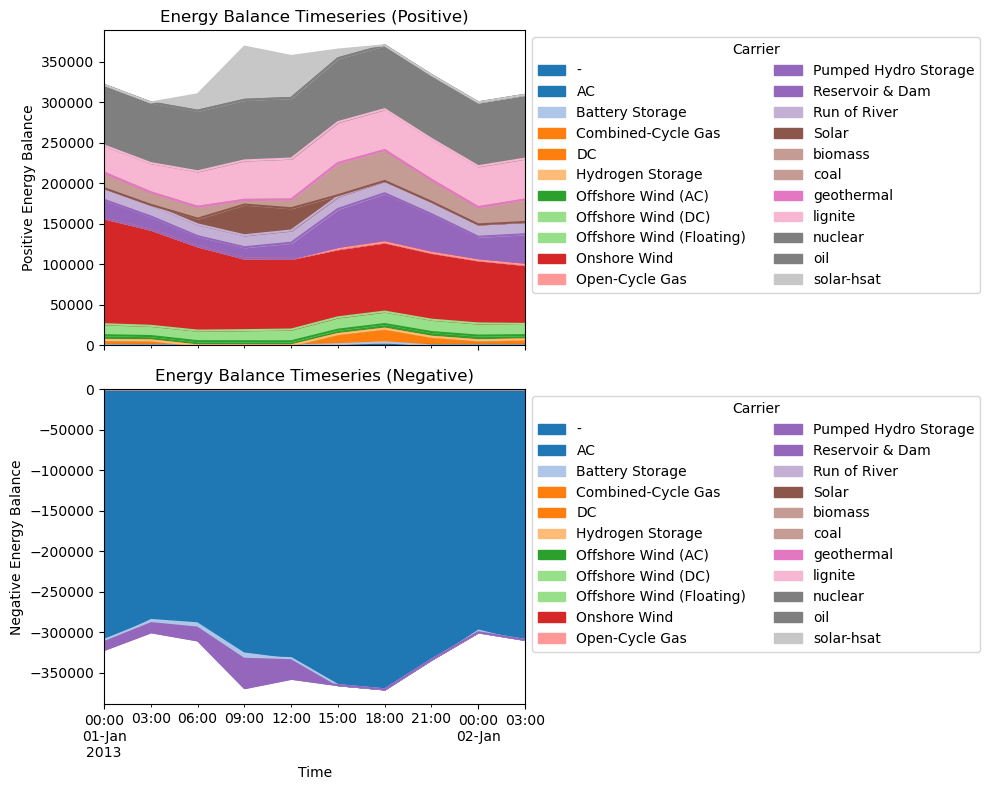

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the energy balance data
energy_balance = network.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[:, :10]

# Sum values by carrier and filter
energy_balance_grouped = energy_balance.groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0)

# Separate positive and negative values
positive_values = energy_balance_grouped.where(energy_balance_grouped > 0, 0)
negative_values = energy_balance_grouped.where(energy_balance_grouped < 0, 0)

# Create subplots
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Plot positive values
positive_values.T.plot.area(ax=ax[0], color=colors, stacked=True, title="Energy Balance Timeseries (Positive)")
ax[0].legend(bbox_to_anchor=(1, 1), loc="upper left", title="Carrier", ncol=2)
ax[0].set_ylabel("Positive Energy Balance")

# Plot negative values
negative_values.T.plot.area(ax=ax[1], color=colors, stacked=True, title="Energy Balance Timeseries (Negative)")
ax[1].legend(bbox_to_anchor=(1, 1), loc="upper left", title="Carrier", ncol=2)
ax[1].set_ylabel("Negative Energy Balance")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


### Whole timeseries

In [14]:
# pypsa.Network.madd()
# init network
n = pypsa.Network()

In [15]:
n = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_50_ec_lv1.0_Co2L{Co2l}.nc")


INFO:pypsa.io:Imported network elec_s_50_ec_lv1.0_Co2L0.6.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


In [19]:

import pypsa
import pandas as pd
import numpy as np

# n = pypsa.Network(snakemake.input.pre)
for Co2l in ['0.05', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6']:
    n_subnetworks = int(2920 / groupsize)
    
    n = pypsa.Network(f"../workflow/prenetworks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}_prepared.nc")
    # sub = "postnetworks/{opts}/sclopf-elec_s_" + NCLUSTERS + "_ec_lv1.0-" + N_ITER + ".nc"


    for i in range(1,n_subnetworks):

        # fn_i = snakemake.input.sub.split('.nc')[0][:-2]+f'{i}.nc'
        # solved sclopf network for one timewindow
        sub_n = pypsa.Network(f"../workflow/postnetworks/Co2L{Co2l}/sclopf-elec_s_" + str(NCLUSTERS) + "_ec_lv1.0-" + f'{i}' + ".nc")#pypsa.Network(fn_i)

        # snapshots in timewindow
        snapshots = sub_n.snapshots
        
        # add data for specific timewindow 
        for key in n.lines_t.keys():
            n.lines_t[key].loc[snapshots, sub_n.lines_t[key].columns] = (
                sub_n.lines_t[key].loc[snapshots, :]
            )

        for key in n.links_t.keys():
            n.links_t[key].loc[snapshots, :] = sub_n.links_t[key].loc[snapshots, :]

        for key in n.generators_t.keys():
            n.generators_t[key].loc[snapshots, :] = sub_n.generators_t[key].loc[snapshots, :]

        for key in n.storage_units_t.keys():
            n.storage_units_t[key].loc[snapshots, :] = sub_n.storage_units_t[key].loc[snapshots, :]

        for key in n.loads_t.keys():
            n.loads_t[key].loc[snapshots, :] = sub_n.loads_t[key].loc[snapshots, :]

    # export network data
    n.export_to_netcdf(f"../workflow/postnetworks/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc")


INFO:pypsa.io:Imported network elec_s_100_ec_lv1.0_Co2L0.05_prepared.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-3.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-4.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0-5.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf

INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.05.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.05 CO2 shadow price: -206.68681533699103


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.1.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.1 CO2 shadow price: -76.30303345257728


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


...

0.4 CO2 shadow price: -21.638301456441116


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.5.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.5 CO2 shadow price: -14.242812022248023


INFO:pypsa.io:Imported network sclopf-elec_s_100_ec_lv1.0_Co2L0.6.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


0.6 CO2 shadow price: -4.814621380802903


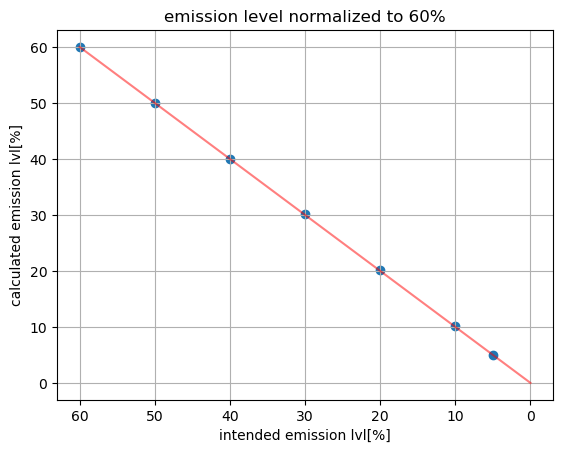

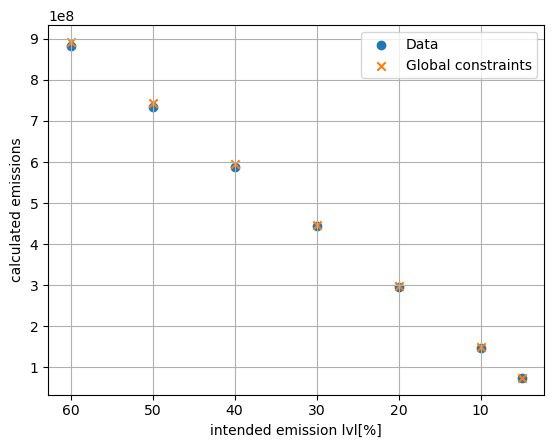

In [10]:
Co2_scenarios = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

test = pd.DataFrame()

os.makedirs('pics/sclopf', exist_ok=True)

# Define the carriers
renewable_carriers = ["solar", "solar-hsat", "onwind", "offwind-ac", "offwind-dc", "offwind-float", "hydro"]
conventional_carriers = ["nuclear", "oil", "OCGT", "CCGT", "coal", "lignite", "geothermal", "biomass"]

# Combine them into a single list for the DataFrame columns
all_carriers = renewable_carriers + conventional_carriers#network.gener.index

generation_by_carrier_and_co2l = pd.DataFrame(None,index=all_carriers, columns= Co2_scenarios)

CO2_shadowprices = pd.Series(index = Co2_scenarios)
CO2_values = pd.Series(index = Co2_scenarios)
lopf_CO2_global = pd.Series(index = Co2_scenarios)
# emissions = pd.Dataframe(None,index = [0], columns = Co2_scenarios)

for Co2l in Co2_scenarios:

    network = pypsa.Network(f"../workflow/postnetworks/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc") #sclopf network

    shadow_CO2 = network.global_constraints["mu"]["CO2Limit"]
    lopf_CO2_global[Co2l] = network.global_constraints["constant"]["CO2Limit"]

    CO2_shadowprices[Co2l] = shadow_CO2
    CO2_values[Co2l] = get_emissions(network)

    print(f"{Co2l} CO2 shadow price: {shadow_CO2}")


    df = network.generators_t.p.sum(axis=0)
    
    # remove carrier id
    df.index = df.index.str[6:]
    # aggregate same carrier types
    df = df.groupby(df.index).sum()


    for carrier in df.index:
        
        # print(f"{carrier} {df[carrier]}")
        generation_by_carrier_and_co2l.loc[carrier, Co2l] = df[carrier]
        # generation_by_carrier_and_co2l.loc[carrier, "co2_emissions"] = network.carriers.co2_emissions[carrier]#df[carrier]
        
    
    # plot energy balance with inbuilt energy_balance method
    
    # number of different carriers
    num_bars = len(network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum())
    
    # colors
    cmap = matplotlib.colormaps.get_cmap('tab20')
    colors = cmap(np.linspace(0, 1, num_bars))
    
    # plot
    fig, ax = plt.subplots(figsize=(10, 6),layout = "constrained")
    # tmp.rename({"-":"Load"},inplace=True)
    # data in plot
    # energy_balance_data = 
    network.statistics.energy_balance().loc[:, :, "AC"].groupby(
        "carrier"
    ).sum().rename({"-":"Load"}).to_frame().T.plot.bar(stacked=True, ax=ax, color=colors, title=f"Energy Balance {Co2l}")
    
    
    ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)
    fig.savefig(f"pics/sclopf/Energymix_sclopf_{Co2l}-{NCLUSTERS}.pdf")
    plt.close()


### Test w/ statistics module
n = network

groupers = n.statistics.groupers
n.statistics.supply(groupby=groupers.get_carrier)

dftmp = pd.DataFrame(n.statistics.supply(groupby=groupers.get_carrier)
)
# generation_fossil = generation_by_carrier_and_co2l.loc[["coal", "lignite", "CCGT", "OCGT"]].sum(axis=0)
# fossil_percentage = generation_fossil.div(generation_by_carrier_and_co2l.sum(axis=0) - generation_fossil)*100

# emission_by_carrier_by_co2l = generation_by_carrier_and_co2l.mul(network.carriers.co2_emissions, axis="index")
# emission_by_carrier_by_co2l.dropna(axis=0, thresh=1, inplace=True)
emission_by_co2l = CO2_values#emission_by_carrier_by_co2l.sum(axis=0)
emission_by_co2l_perc = emission_by_co2l/emission_by_co2l[0.6]*60

# plot red line
plt.plot([60,0],[60,0], color = "r", alpha = 0.5)
# plot 

plt.scatter(emission_by_co2l_perc.index*100, emission_by_co2l_perc.values)

plt.gca().invert_xaxis()
plt.grid()
plt.title("emission level normalized to 60%")
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emission lvl[%]")

plt.figure()
plt.scatter(emission_by_co2l.index*100, emission_by_co2l.values,label = "Data")
plt.scatter(lopf_CO2_global.index*100, lopf_CO2_global.values,label = "Global constraints",marker = "x")

plt.legend()
plt.gca().invert_xaxis()
plt.grid()
plt.xlabel("intended emission lvl[%]")
plt.ylabel("calculated emissions")
plt.savefig(f"pics/sclopf/emissions-{NCLUSTERS}.pdf")